# Árvores de Decisão e XGBoost
## Previsão de Produtividade Agrícola (sacas/hectare)

No notebook anterior, conseguimos ajustar uma curva polinomial a uma única variável. Agora avançamos para um problema **multivariado** com várias relações não lineares ao mesmo tempo.

Trabalharemos com a previsão de **produtividade de uma cultura agrícola** (em sacas por hectare) a partir de fatores como temperatura, chuva, qualidade do solo, fertilizante, horas de sol e pH.

Características que tornam o problema **não linear**:
- A produtividade tem uma faixa **ótima** de temperatura, precipitação e pH — fora dela, cai dos dois lados.
- Fertilizante apresenta **retorno decrescente** (dobrar a dose não dobra o resultado).
- Diferentes variáveis interagem entre si.

Para esse tipo de problema, modelos baseados em **árvores de decisão** costumam ser a melhor escolha.

## Conceito: Árvores de Decisão e Boosting

### Árvore de Decisão

Uma árvore de regressão divide repetidamente os dados em sub-regiões, e em cada folha prediz a média do alvo daquela região. Não é necessário "linearizar" nem padronizar nada — a árvore lida naturalmente com:
- Relações não lineares.
- Interações entre variáveis.
- Escalas diferentes.

A desvantagem clássica: uma única árvore tende a **sobreajustar** os dados.

### Gradient Boosting (XGBoost)

O **XGBoost** é uma das implementações mais usadas de **Gradient Boosted Trees**: em vez de uma única árvore, ele treina uma sequência de árvores em que cada nova árvore tenta corrigir os erros das anteriores.

Vantagens:
- Excelente desempenho preditivo.
- Lida bem com não linearidades e interações.
- Tem regularização interna que reduz o sobreajuste.

Hoje é praticamente padrão em competições e em muitos sistemas de produção.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 600 registros de safras agrícolas com características climáticas e de manejo, e a produtividade resultante (em sacas por hectare).

In [2]:
df = pd.read_csv('dados_produtividade_agricola.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 600 linhas × 7 colunas


,temperatura_media_c,precipitacao_mm,qualidade_solo,fertilizante_kg_ha,horas_sol_dia,ph_solo,produtividade_sacas_ha
0,20.41,442.1,5,175.9,10.78,8.36,5.99
1,22.28,566.5,6,394.2,9.51,7.76,142.65
2,21.29,1683.6,8,394.0,7.68,7.39,173.00
3,18.15,850.1,6,362.4,6.31,7.98,150.71
4,17.96,1251.4,7,319.4,3.45,8.13,97.43
5,33.72,1051.0,9,107.7,4.29,5.85,125.14
6,23.76,960.6,10,128.3,4.74,6.94,176.07
7,22.67,1144.6,2,218.9,6.36,6.94,173.23
8,29.59,662.1,8,224.3,11.50,5.57,77.71
9,26.06,1784.0,3,202.2,7.55,5.39,131.30


In [3]:
df.describe().round(2)

,temperatura_media_c,precipitacao_mm,qualidade_solo,fertilizante_kg_ha,horas_sol_dia,ph_solo,produtividade_sacas_ha
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,24.96,1105.44,5.58,194.76,7.50,6.49,101.92
std,5.90,405.72,2.87,116.39,2.59,1.18,47.14
min,15.02,400.70,1.00,1.90,3.01,4.50,5.00
25%,19.83,754.18,3.00,97.82,5.20,5.49,70.85
50%,24.92,1078.40,6.00,191.00,7.55,6.50,104.71
75%,30.18,1458.62,8.00,294.25,9.72,7.53,136.44
max,34.98,1799.20,10.00,399.90,11.99,8.50,220.17


## 3. Análise Exploratória

### 3.1 Distribuições

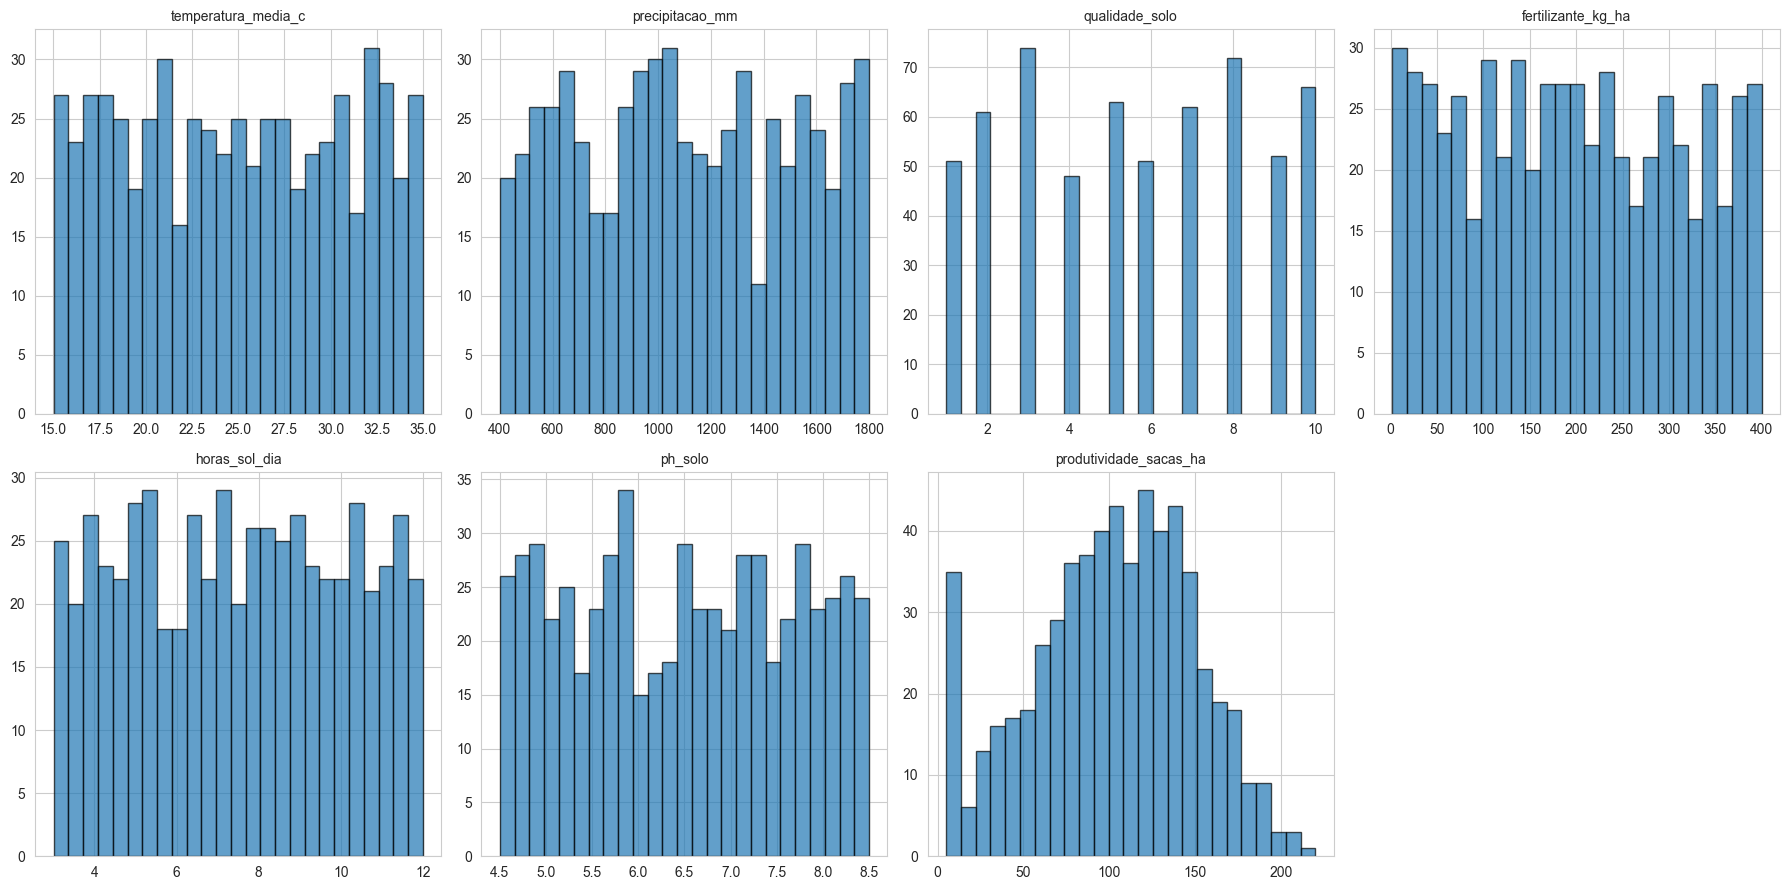

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)

if len(df.columns) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Correlação Linear com a Produtividade

In [5]:
corr_alvo = df.corr()['produtividade_sacas_ha'].drop('produtividade_sacas_ha').sort_values(ascending=False)
print('Correlação linear com produtividade:\n')
for var, c in corr_alvo.items():
    print(f'  {var:<25s} {c:>+.4f}')

Correlação linear com produtividade:

  fertilizante_kg_ha        +0.5715
  qualidade_solo            +0.2382
  temperatura_media_c       +0.0563
  ph_solo                   +0.0441
  precipitacao_mm           +0.0244
  horas_sol_dia             -0.2393


**Importante:** correlações lineares baixas **não** significam que a variável é irrelevante.

Por exemplo, a temperatura tem uma faixa ótima — temperaturas muito baixas ou muito altas reduzem a produtividade. Esse comportamento em formato de "U invertido" tem correlação **linear** próxima de zero, mesmo sendo uma relação extremamente forte. As árvores conseguem capturar esse tipo de padrão.

### 3.3 Visualizando Não Linearidades

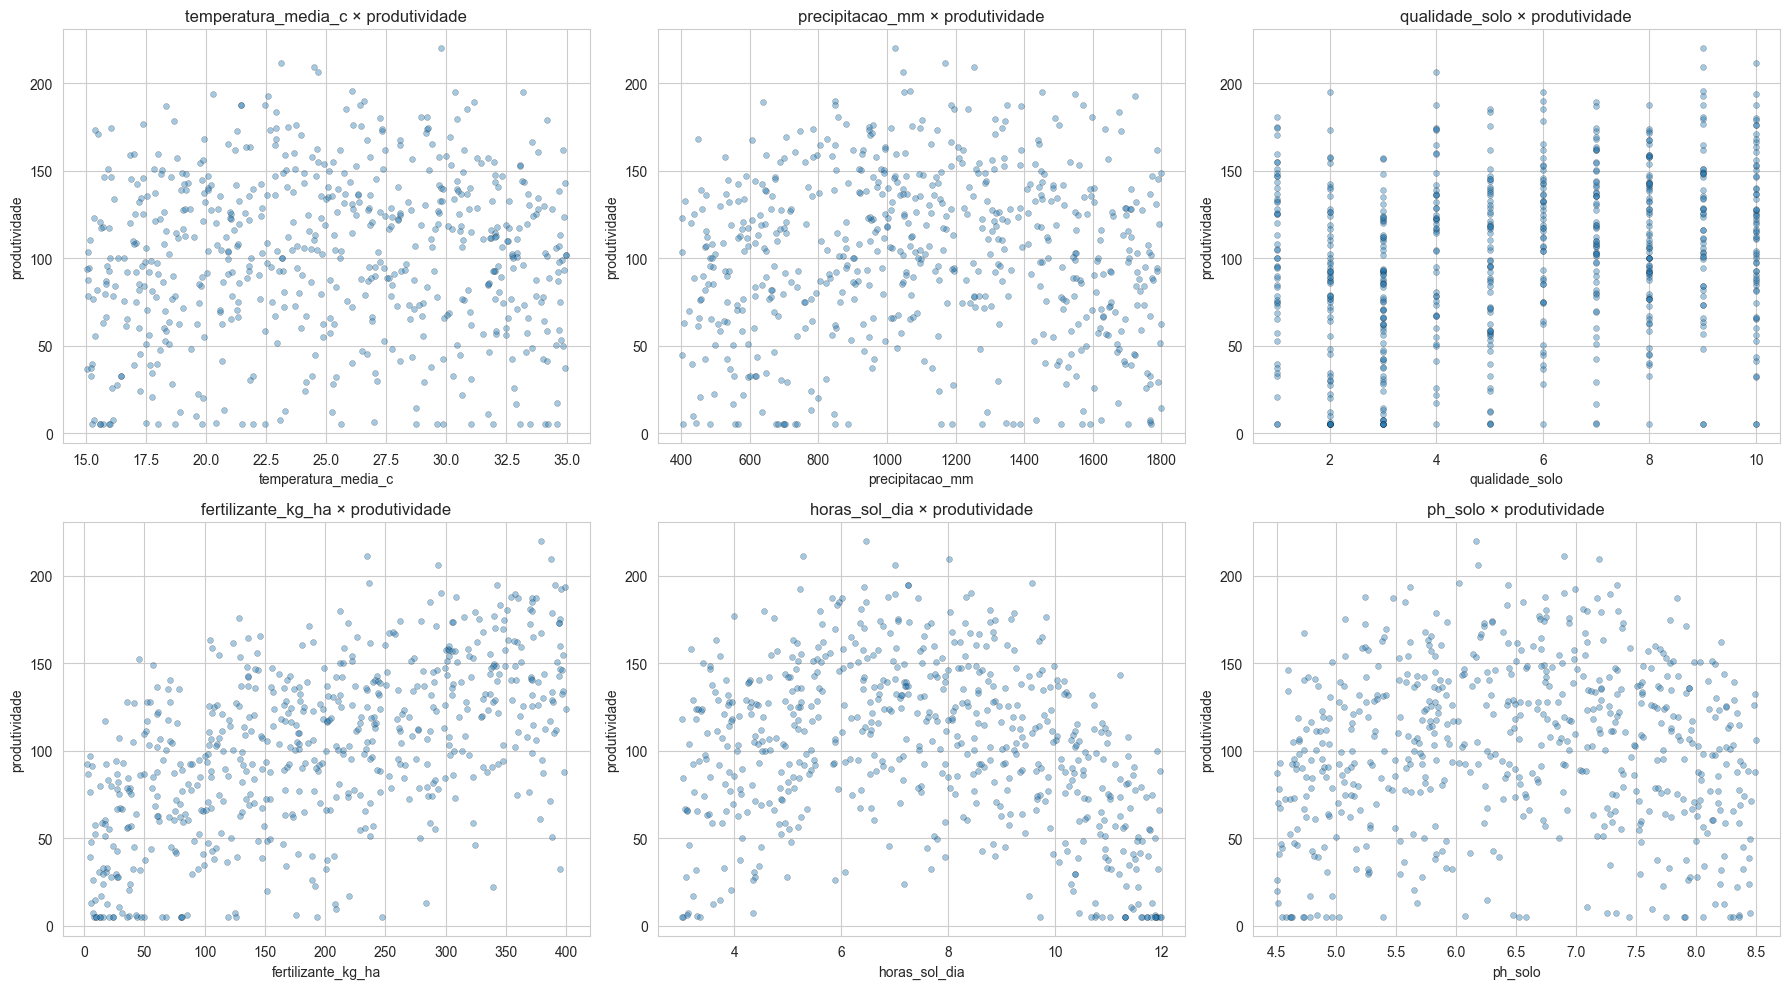

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = ['temperatura_media_c', 'precipitacao_mm', 'qualidade_solo',
            'fertilizante_kg_ha', 'horas_sol_dia', 'ph_solo']

for ax, col in zip(axes.flatten(), features):
    ax.scatter(df[col], df['produtividade_sacas_ha'], alpha=0.4, s=18,
               edgecolors='k', linewidths=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('produtividade')
    ax.set_title(f'{col} × produtividade')

plt.tight_layout()
plt.show()

Note como várias variáveis (temperatura, precipitação, horas de sol, pH) apresentam um claro **formato de sino**. Tentar ajustar uma reta nesses casos não funcionaria.

## 4. Preparação dos Dados

In [7]:
X = df.drop(columns='produtividade_sacas_ha')
y = df['produtividade_sacas_ha']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 480 amostras
Teste:  120 amostras


**Observação:** modelos baseados em árvore **não exigem padronização** das variáveis (`StandardScaler`). As divisões binárias da árvore são invariantes a transformações monotônicas das features.

## 5. Modelo 1 — Árvore de Decisão (sem limites)

Vamos começar com uma árvore "crescendo livre" para ilustrar o problema do sobreajuste.

In [8]:
arvore_full = DecisionTreeRegressor(random_state=42)
arvore_full.fit(X_treino, y_treino)

r2_treino = r2_score(y_treino, arvore_full.predict(X_treino))
r2_teste  = r2_score(y_teste,  arvore_full.predict(X_teste))

print(f'Profundidade da árvore: {arvore_full.get_depth()}')
print(f'Folhas: {arvore_full.get_n_leaves()}\n')
print(f'R² Treino: {r2_treino:.4f}')
print(f'R² Teste:  {r2_teste:.4f}')

Profundidade da árvore: 18
Folhas: 471

R² Treino: 1.0000
R² Teste:  0.6786


O R² no treino chega a 1.0 (a árvore "decora" os dados), mas no teste cai consideravelmente. Esse é o sintoma clássico de **sobreajuste**.

## 6. Controlando o Sobreajuste — Profundidade Máxima

Vamos limitar a profundidade da árvore e observar o efeito.

In [9]:
profundidades = [2, 3, 4, 5, 6, 8, 10, 15, None]

resultados_arvore = []
for d in profundidades:
    arv = DecisionTreeRegressor(max_depth=d, random_state=42)
    arv.fit(X_treino, y_treino)
    resultados_arvore.append({
        'max_depth': str(d),
        'R² Treino': r2_score(y_treino, arv.predict(X_treino)),
        'R² Teste':  r2_score(y_teste,  arv.predict(X_teste)),
    })

df_arvore = pd.DataFrame(resultados_arvore)
df_arvore.round(4)

,max_depth,R² Treino,R² Teste
0,2,0.4196,0.4722
1,3,0.5314,0.5384
2,4,0.6349,0.5662
3,5,0.7450,0.6339
4,6,0.8150,0.6654
5,8,0.9173,0.6841
6,10,0.9690,0.7056
7,15,0.9995,0.6365
8,None,1.0000,0.6786


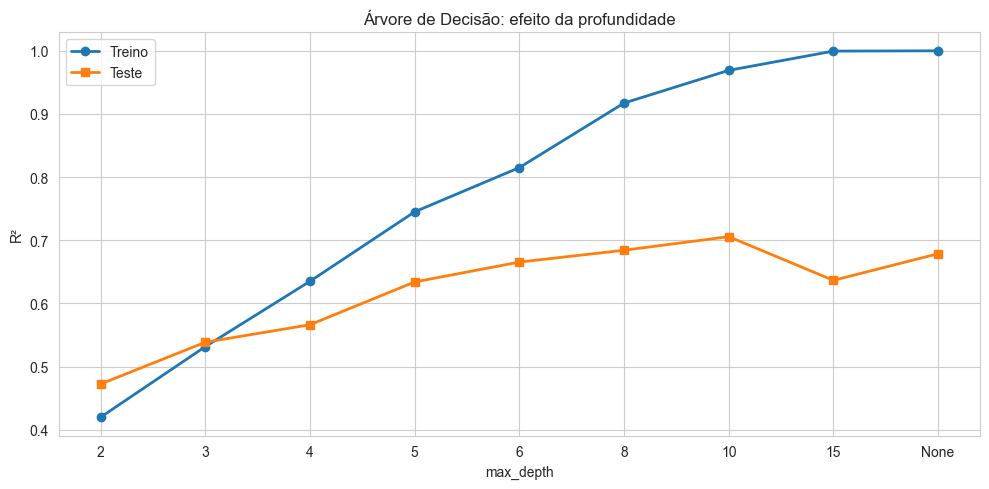

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(df_arvore)), df_arvore['R² Treino'], marker='o', label='Treino', linewidth=2)
ax.plot(range(len(df_arvore)), df_arvore['R² Teste'],  marker='s', label='Teste',  linewidth=2)
ax.set_xticks(range(len(df_arvore)))
ax.set_xticklabels(df_arvore['max_depth'])
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Árvore de Decisão: efeito da profundidade')
ax.legend()
plt.tight_layout()
plt.show()

Observe a tesoura abrindo: o R² de treino sobe sempre, mas o de teste estabiliza (ou cai) a partir de certa profundidade. O melhor `max_depth` aqui está em torno de **5–8**.

## 7. Árvore Final (com profundidade controlada)

In [11]:
arvore = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
arvore.fit(X_treino, y_treino)

y_pred_arv = arvore.predict(X_teste)

r2_arv  = r2_score(y_teste, y_pred_arv)
mae_arv = mean_absolute_error(y_teste, y_pred_arv)
rmse_arv = np.sqrt(mean_squared_error(y_teste, y_pred_arv))

print(f'=== Árvore de Decisão ===')
print(f'R²:   {r2_arv:.4f}')
print(f'MAE:  {mae_arv:.2f} sacas/ha')
print(f'RMSE: {rmse_arv:.2f} sacas/ha')

=== Árvore de Decisão ===
R²:   0.6699
MAE:  23.62 sacas/ha
RMSE: 28.65 sacas/ha


### Visualizando a Árvore (top 3 níveis)

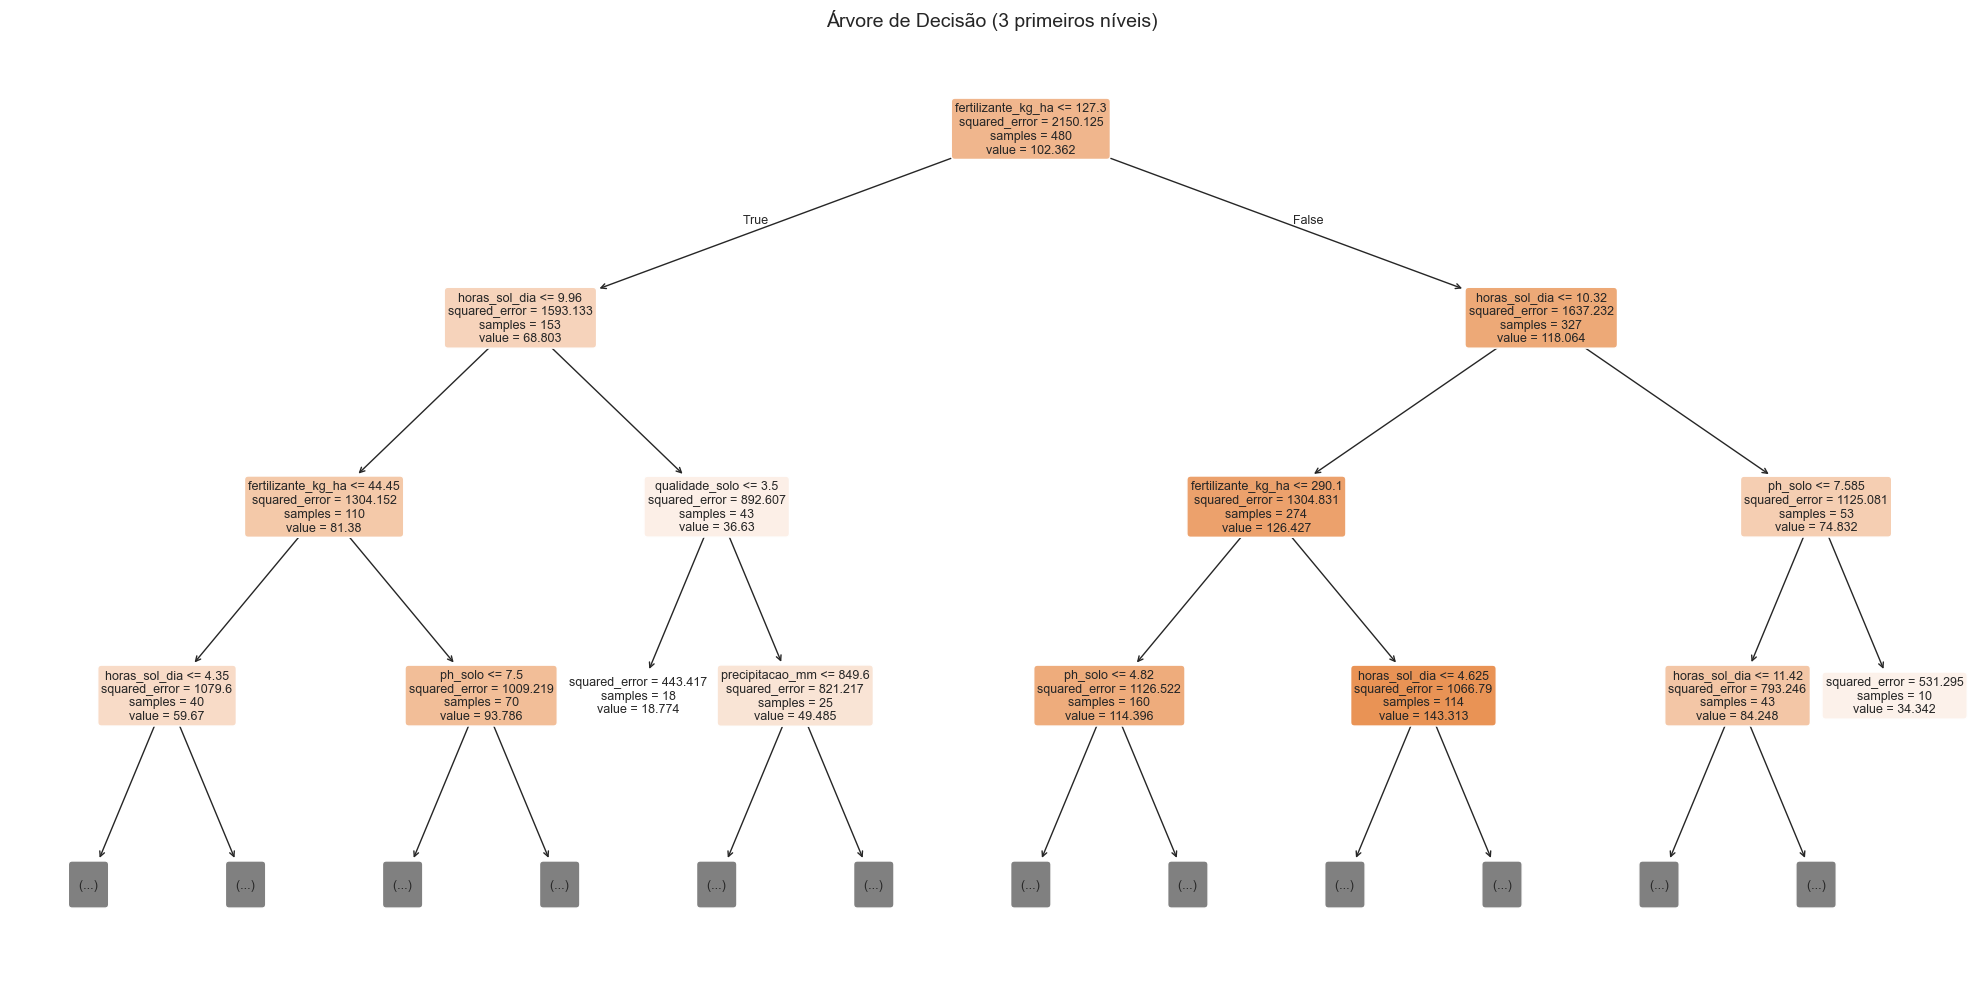

In [12]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    arvore, max_depth=3,
    feature_names=X.columns, filled=True, rounded=True,
    fontsize=9, ax=ax
)
plt.title('Árvore de Decisão (3 primeiros níveis)', fontsize=14)
plt.tight_layout()
plt.show()

Cada nó interno mostra a regra de divisão escolhida pelo algoritmo. Note como a árvore prioriza variáveis como temperatura e fertilizante.

### Importância das Variáveis

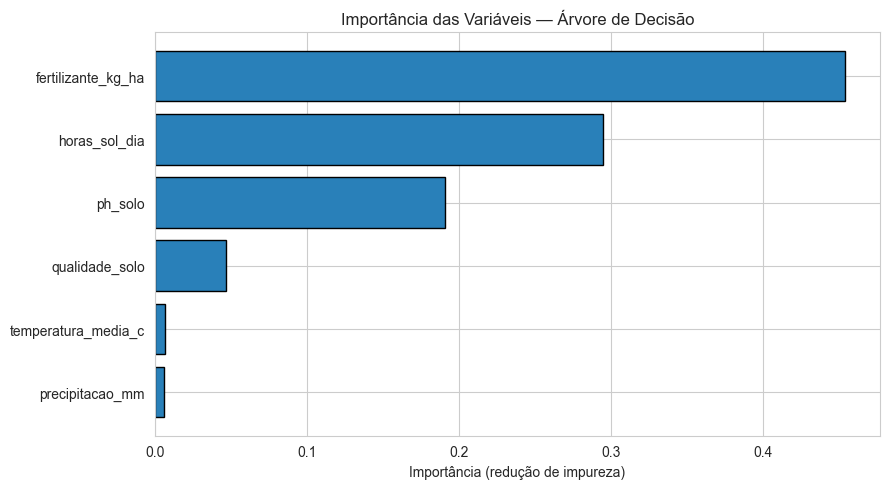

In [13]:
importancias_arv = pd.DataFrame({
    'Variável': X.columns,
    'Importância': arvore.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importancias_arv['Variável'], importancias_arv['Importância'],
         color='#2980b9', edgecolor='black')
plt.title('Importância das Variáveis — Árvore de Decisão')
plt.xlabel('Importância (redução de impureza)')
plt.tight_layout()
plt.show()

## 8. Modelo 2 — XGBoost

O XGBoost combina muitas árvores rasas, cada uma corrigindo os erros das anteriores. Vamos treinar uma versão padrão e depois ajustar alguns hiperparâmetros.

In [14]:
xgb_v1 = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_v1.fit(X_treino, y_treino)

y_pred_xgb = xgb_v1.predict(X_teste)

r2_xgb  = r2_score(y_teste, y_pred_xgb)
mae_xgb = mean_absolute_error(y_teste, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_teste, y_pred_xgb))

print(f'=== XGBoost (config padrão) ===')
print(f'R²:   {r2_xgb:.4f}')
print(f'MAE:  {mae_xgb:.2f} sacas/ha')
print(f'RMSE: {rmse_xgb:.2f} sacas/ha')

=== XGBoost (config padrão) ===
R²:   0.8929
MAE:  12.27 sacas/ha
RMSE: 16.32 sacas/ha


### Hiperparâmetros principais do XGBoost

- `n_estimators`: número de árvores. Mais árvores → mais capacidade, porém mais lento.
- `max_depth`: profundidade de cada árvore. Em boosting, costuma ser pequeno (3–8).
- `learning_rate`: o quanto cada árvore contribui. Menor → precisa de mais árvores, mas costuma generalizar melhor.
- `subsample`: fração de dados usada por árvore (introduz aleatoriedade → reduz sobreajuste).
- `colsample_bytree`: fração de colunas amostradas por árvore.

### Busca Manual por uma Boa Configuração

In [15]:
configs = [
    {'n_estimators': 100,  'max_depth': 3, 'learning_rate': 0.20},
    {'n_estimators': 200,  'max_depth': 4, 'learning_rate': 0.10},
    {'n_estimators': 400,  'max_depth': 4, 'learning_rate': 0.05},
    {'n_estimators': 600,  'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 800,  'max_depth': 6, 'learning_rate': 0.03},
]

resultados_xgb = []
for cfg in configs:
    m = XGBRegressor(**cfg, subsample=0.9, colsample_bytree=0.9,
                     random_state=42, n_jobs=-1)
    m.fit(X_treino, y_treino)
    resultados_xgb.append({
        **cfg,
        'R² Teste': r2_score(y_teste, m.predict(X_teste)),
        'RMSE Teste': np.sqrt(mean_squared_error(y_teste, m.predict(X_teste)))
    })

df_xgb = pd.DataFrame(resultados_xgb)
df_xgb.round(4)

,n_estimators,max_depth,learning_rate,R² Teste,RMSE Teste
0,100,3,0.20,0.9256,13.6034
1,200,4,0.10,0.8999,15.7786
2,400,4,0.05,0.9106,14.9096
3,600,5,0.05,0.8796,17.3015
4,800,6,0.03,0.8768,17.5057


### Modelo XGBoost Final

In [16]:
xgb_final = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_treino, y_treino)

y_pred_xgb_final = xgb_final.predict(X_teste)

r2_xgb_final  = r2_score(y_teste, y_pred_xgb_final)
mae_xgb_final = mean_absolute_error(y_teste, y_pred_xgb_final)
rmse_xgb_final = np.sqrt(mean_squared_error(y_teste, y_pred_xgb_final))

print(f'=== XGBoost (final) ===')
print(f'R²:   {r2_xgb_final:.4f}')
print(f'MAE:  {mae_xgb_final:.2f} sacas/ha')
print(f'RMSE: {rmse_xgb_final:.2f} sacas/ha')

=== XGBoost (final) ===
R²:   0.8796
MAE:  12.60 sacas/ha
RMSE: 17.30 sacas/ha


### Importância das Variáveis (XGBoost)

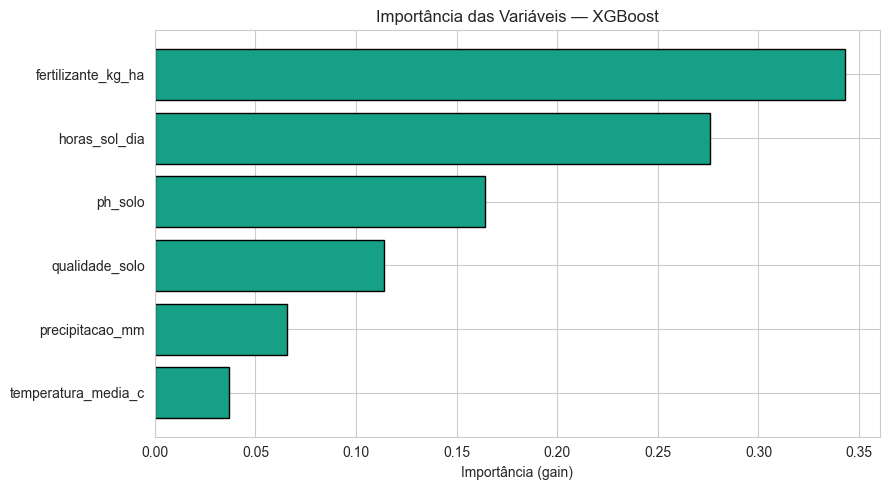

In [17]:
importancias_xgb = pd.DataFrame({
    'Variável': X.columns,
    'Importância': xgb_final.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importancias_xgb['Variável'], importancias_xgb['Importância'],
         color='#16a085', edgecolor='black')
plt.title('Importância das Variáveis — XGBoost')
plt.xlabel('Importância (gain)')
plt.tight_layout()
plt.show()

## 9. Comparação dos Modelos

In [18]:
resultados = pd.DataFrame([
    {'Modelo': 'Árvore de Decisão', 'R²': r2_arv,        'MAE': mae_arv,        'RMSE': rmse_arv},
    {'Modelo': 'XGBoost (padrão)',  'R²': r2_xgb,        'MAE': mae_xgb,        'RMSE': rmse_xgb},
    {'Modelo': 'XGBoost (final)',   'R²': r2_xgb_final,  'MAE': mae_xgb_final,  'RMSE': rmse_xgb_final},
]).set_index('Modelo')

resultados.round(4)

,R²,MAE,RMSE
Modelo,,,
Árvore de Decisão,0.6699,23.6210,28.6510
XGBoost (padrão),0.8929,12.2729,16.3185
XGBoost (final),0.8796,12.6026,17.3015


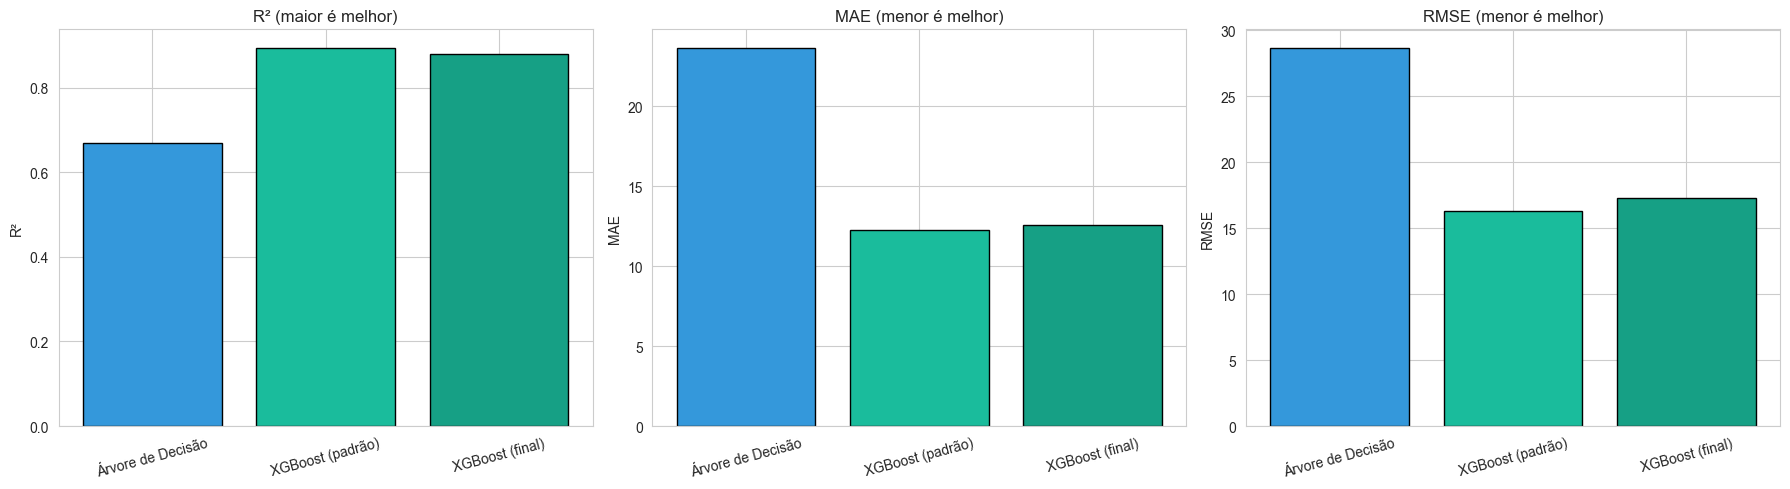

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cores = ['#3498db', '#1abc9c', '#16a085']
for ax, metric, titulo in zip(axes, ['R²', 'MAE', 'RMSE'],
                              ['R² (maior é melhor)',
                               'MAE (menor é melhor)',
                               'RMSE (menor é melhor)']):
    ax.bar(resultados.index, resultados[metric], color=cores, edgecolor='black')
    ax.set_title(titulo)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 10. Validação Cruzada (5-Fold)

In [20]:
from sklearn.tree import DecisionTreeRegressor

modelos_cv = {
    'Árvore (max_depth=6)': DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42),
    'XGBoost (final)':       XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.05,
                                          subsample=0.9, colsample_bytree=0.9,
                                          random_state=42, n_jobs=-1),
}

print('Validação Cruzada (5-fold) — R²:\n')
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_treino, y_treino, cv=5, scoring='r2')
    print(f'  {nome:<25s}  R² = {scores.mean():.4f} ± {scores.std():.4f}')

Validação Cruzada (5-fold) — R²:

  Árvore (max_depth=6)       R² = 0.5057 ± 0.0886


  XGBoost (final)            R² = 0.8717 ± 0.0190


## 11. Valores Reais vs Previstos

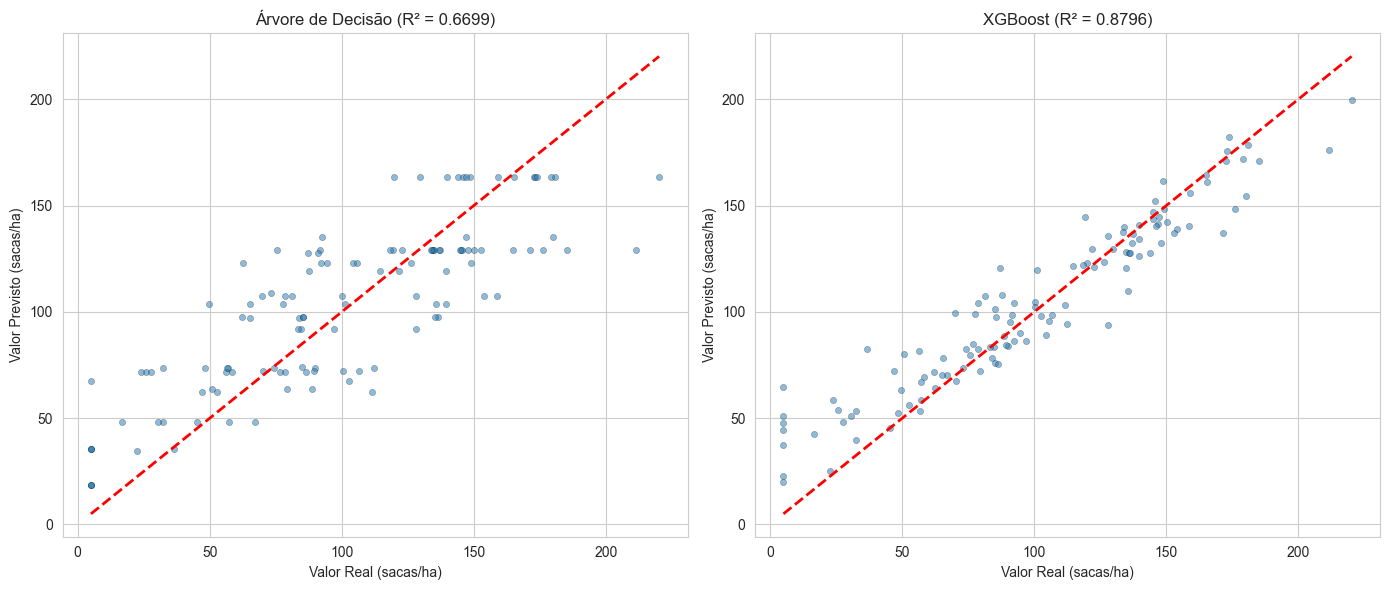

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, y_pred) in zip(axes,
                              [('Árvore de Decisão', y_pred_arv),
                               ('XGBoost', y_pred_xgb_final)]):
    ax.scatter(y_teste, y_pred, alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
    lims = [min(y_teste.min(), y_pred.min()), max(y_teste.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    r2 = r2_score(y_teste, y_pred)
    ax.set_xlabel('Valor Real (sacas/ha)')
    ax.set_ylabel('Valor Previsto (sacas/ha)')
    ax.set_title(f'{nome} (R² = {r2:.4f})')

plt.tight_layout()
plt.show()

## 12. Análise de Resíduos

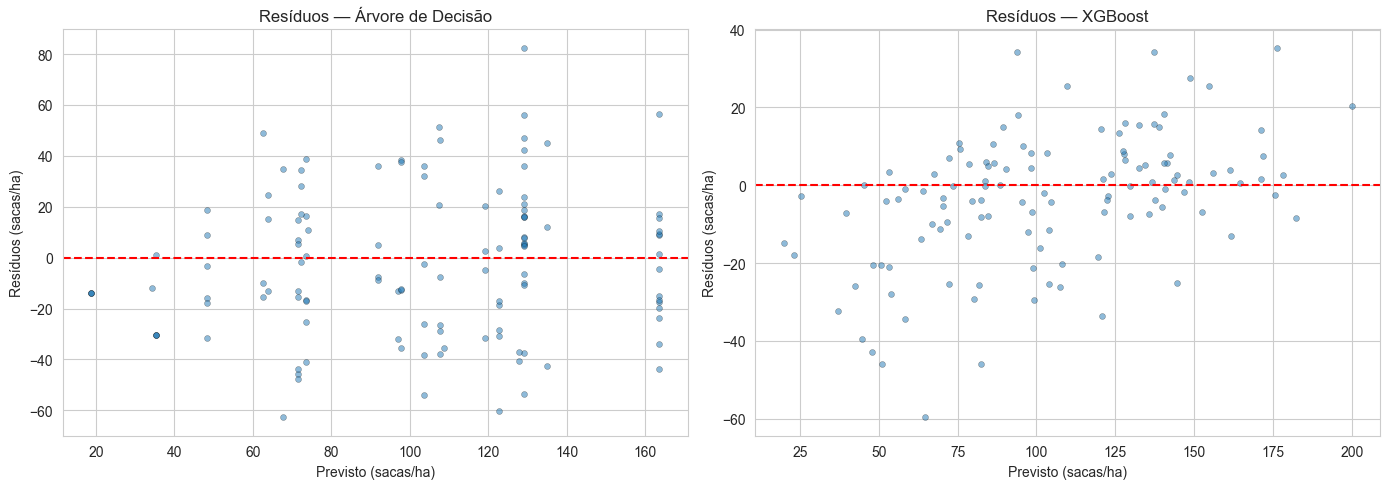

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nome, y_pred) in zip(axes,
                              [('Árvore de Decisão', y_pred_arv),
                               ('XGBoost', y_pred_xgb_final)]):
    residuos = y_teste - y_pred
    ax.scatter(y_pred, residuos, alpha=0.5, s=18, edgecolors='k', linewidths=0.3)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_xlabel('Previsto (sacas/ha)')
    ax.set_ylabel('Resíduos (sacas/ha)')
    ax.set_title(f'Resíduos — {nome}')

plt.tight_layout()
plt.show()

## 13. Previsões em Novos Cenários

In [23]:
novos_cenarios = pd.DataFrame([
    # Cenário ideal: temperatura ~25, precipitação ~1100, sol ~7h, pH ~6.5
    {'temperatura_media_c': 25, 'precipitacao_mm': 1100, 'qualidade_solo': 9,
     'fertilizante_kg_ha': 200, 'horas_sol_dia': 7,  'ph_solo': 6.5},
    # Cenário ruim: muito quente e seco
    {'temperatura_media_c': 33, 'precipitacao_mm': 500,  'qualidade_solo': 4,
     'fertilizante_kg_ha': 80,  'horas_sol_dia': 11, 'ph_solo': 5.5},
    # Cenário com chuva em excesso
    {'temperatura_media_c': 22, 'precipitacao_mm': 1700, 'qualidade_solo': 6,
     'fertilizante_kg_ha': 150, 'horas_sol_dia': 5,  'ph_solo': 7.0},
])

prev_arv = arvore.predict(novos_cenarios)
prev_xgb = xgb_final.predict(novos_cenarios)

novos_cenarios['Previsão Árvore'] = prev_arv.round(2)
novos_cenarios['Previsão XGBoost'] = prev_xgb.round(2)
novos_cenarios

,temperatura_media_c,precipitacao_mm,qualidade_solo,fertilizante_kg_ha,horas_sol_dia,ph_solo,Previsão Árvore,Previsão XGBoost
0,25,1100,9,200,7,6.5,129.15,179.169998
1,33,500,4,80,11,5.5,35.37,27.709999
2,22,1700,6,150,5,7.0,129.15,114.110001


## Conclusão

- A produtividade agrícola é um caso típico de **regressão não linear multivariada**: variáveis com faixas ótimas, retorno decrescente e interações.
- Uma **única árvore de decisão** capta as não linearidades, mas tende ao sobreajuste se não controlarmos `max_depth` e `min_samples_leaf`.
- O **XGBoost** une múltiplas árvores fracas e supera consistentemente a árvore individual.
- Tree-based models não exigem padronização nem transformações de variáveis — uma grande vantagem operacional.

No próximo notebook, vamos comparar **quatro modelos** diferentes em um problema ainda mais rico, com variáveis numéricas e categóricas misturadas.